# 01 — EDA & Preprocessing
## Universal Sequence Lab · Assignment 3

This notebook covers **Exploratory Data Analysis and preprocessing** for all three data modalities used in this project:

| Module | Data | Task |
|--------|------|------|
| **A** | IMDb Reviews (text) | Sentiment Classification |
| **B** | Jena Climate (tabular) | Temperature Forecasting |
| **C** | Multi30k (parallel text) | EN→DE Translation |

---

In [6]:
# ── Install dependencies ──────────────────────────────────────────────
!pip install datasets sacrebleu seaborn scikit-learn -q


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import sys, os
sys.path.append('/content/src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('Dependencies loaded ✓')

Dependencies loaded ✓


## Module A — IMDb Text Dataset


In [8]:
from datasets import load_dataset
imdb = load_dataset('imdb')
print(imdb)
print('\nSample review:')
print(imdb['train'][0]['text'][:400])
print('Label:', imdb['train'][0]['label'])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Sample review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student name
Label: 0


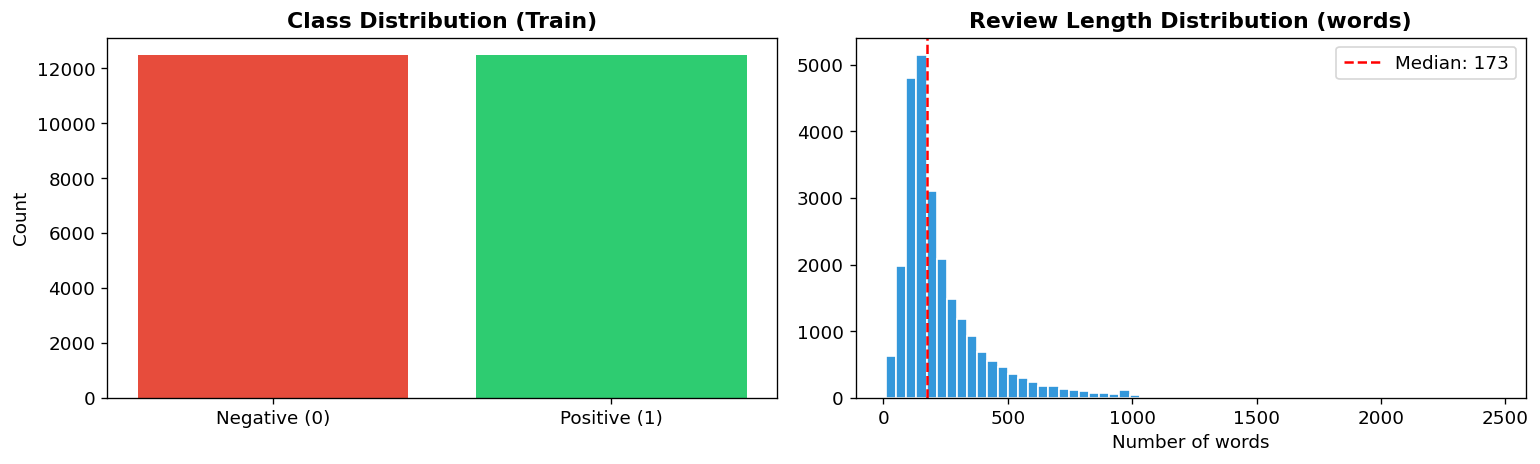

Median length: 173 | 95th pct: 592


In [9]:
# ── Label distribution ────────────────────────────────────────────────
labels = [ex['label'] for ex in imdb['train']]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Class balance
axes[0].bar(['Negative (0)', 'Positive (1)'],
            [labels.count(0), labels.count(1)], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Class Distribution (Train)', fontweight='bold')
axes[0].set_ylabel('Count')

# Review length distribution
import re
lengths = [len(re.sub(r'<[^>]+>', ' ', ex['text']).split()) for ex in imdb['train']]
axes[1].hist(lengths, bins=60, color='#3498db', edgecolor='white')
axes[1].axvline(np.median(lengths), color='red', linestyle='--',
                label=f'Median: {int(np.median(lengths))}')
axes[1].set_title('Review Length Distribution (words)', fontweight='bold')
axes[1].set_xlabel('Number of words')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_imdb.png', bbox_inches='tight')
plt.show()
print(f'Median length: {np.median(lengths):.0f} | 95th pct: {np.percentile(lengths, 95):.0f}')

  Vocabulary size: 25,004


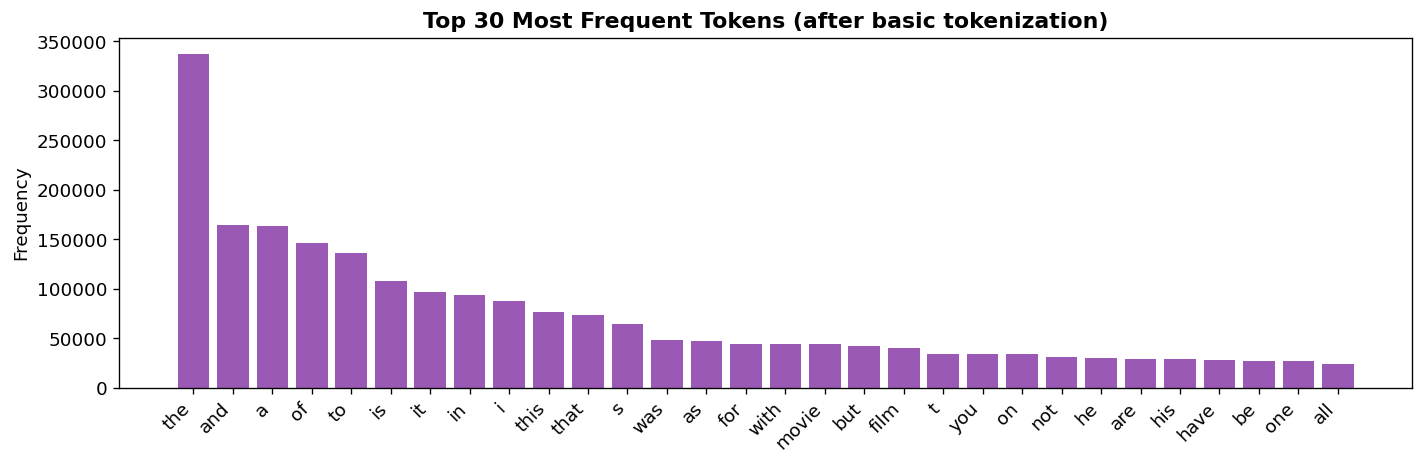


Vocab size (min_freq=3): 25,004
Special tokens: ['<pad>', '<unk>', '<sos>', '<eos>']


In [10]:
# ── Vocabulary analysis ───────────────────────────────────────────────
from dataset import simple_tokenize, Vocabulary

vocab = Vocabulary(min_freq=3)
vocab.build([ex['text'] for ex in imdb['train']])

# Most common words
all_tokens = []
for ex in imdb['train']:
    all_tokens.extend(simple_tokenize(ex['text']))
top30 = Counter(all_tokens).most_common(30)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar([w for w, _ in top30], [c for _, c in top30], color='#9b59b6')
ax.set_title('Top 30 Most Frequent Tokens (after basic tokenization)', fontweight='bold')
ax.set_ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f'\nVocab size (min_freq=3): {len(vocab):,}')
print('Special tokens:', list(vocab.token2idx.keys())[:4])

## Module B — Jena Climate Time Series


In [11]:
url = 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip'
df = pd.read_csv(url, compression='zip')
df = df.iloc[::6].reset_index(drop=True)  # hourly
df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
df = df.set_index('Date Time')

features = ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'Tdew (degC)']
print(df[features].describe().round(2))
print(f'\nTotal time steps: {len(df):,}')
print(f'Date range: {df.index[0]} → {df.index[-1]}')

       T (degC)  p (mbar)    rh (%)  wv (m/s)  Tdew (degC)
count  70092.00  70092.00  70092.00  70092.00     70092.00
mean       9.45    989.21     76.01      1.70         4.96
std        8.42      8.36     16.48     65.45         6.73
min      -23.01    914.10     14.20  -9999.00       -25.01
25%        3.36    984.20     65.21      0.99         0.23
50%        9.42    989.58     79.30      1.76         5.22
75%       15.47    994.72     89.40      2.86        10.06
max       37.13   1015.28    100.00     28.49        23.11

Total time steps: 70,092
Date range: 2009-01-01 00:10:00 → 2016-12-31 23:20:00


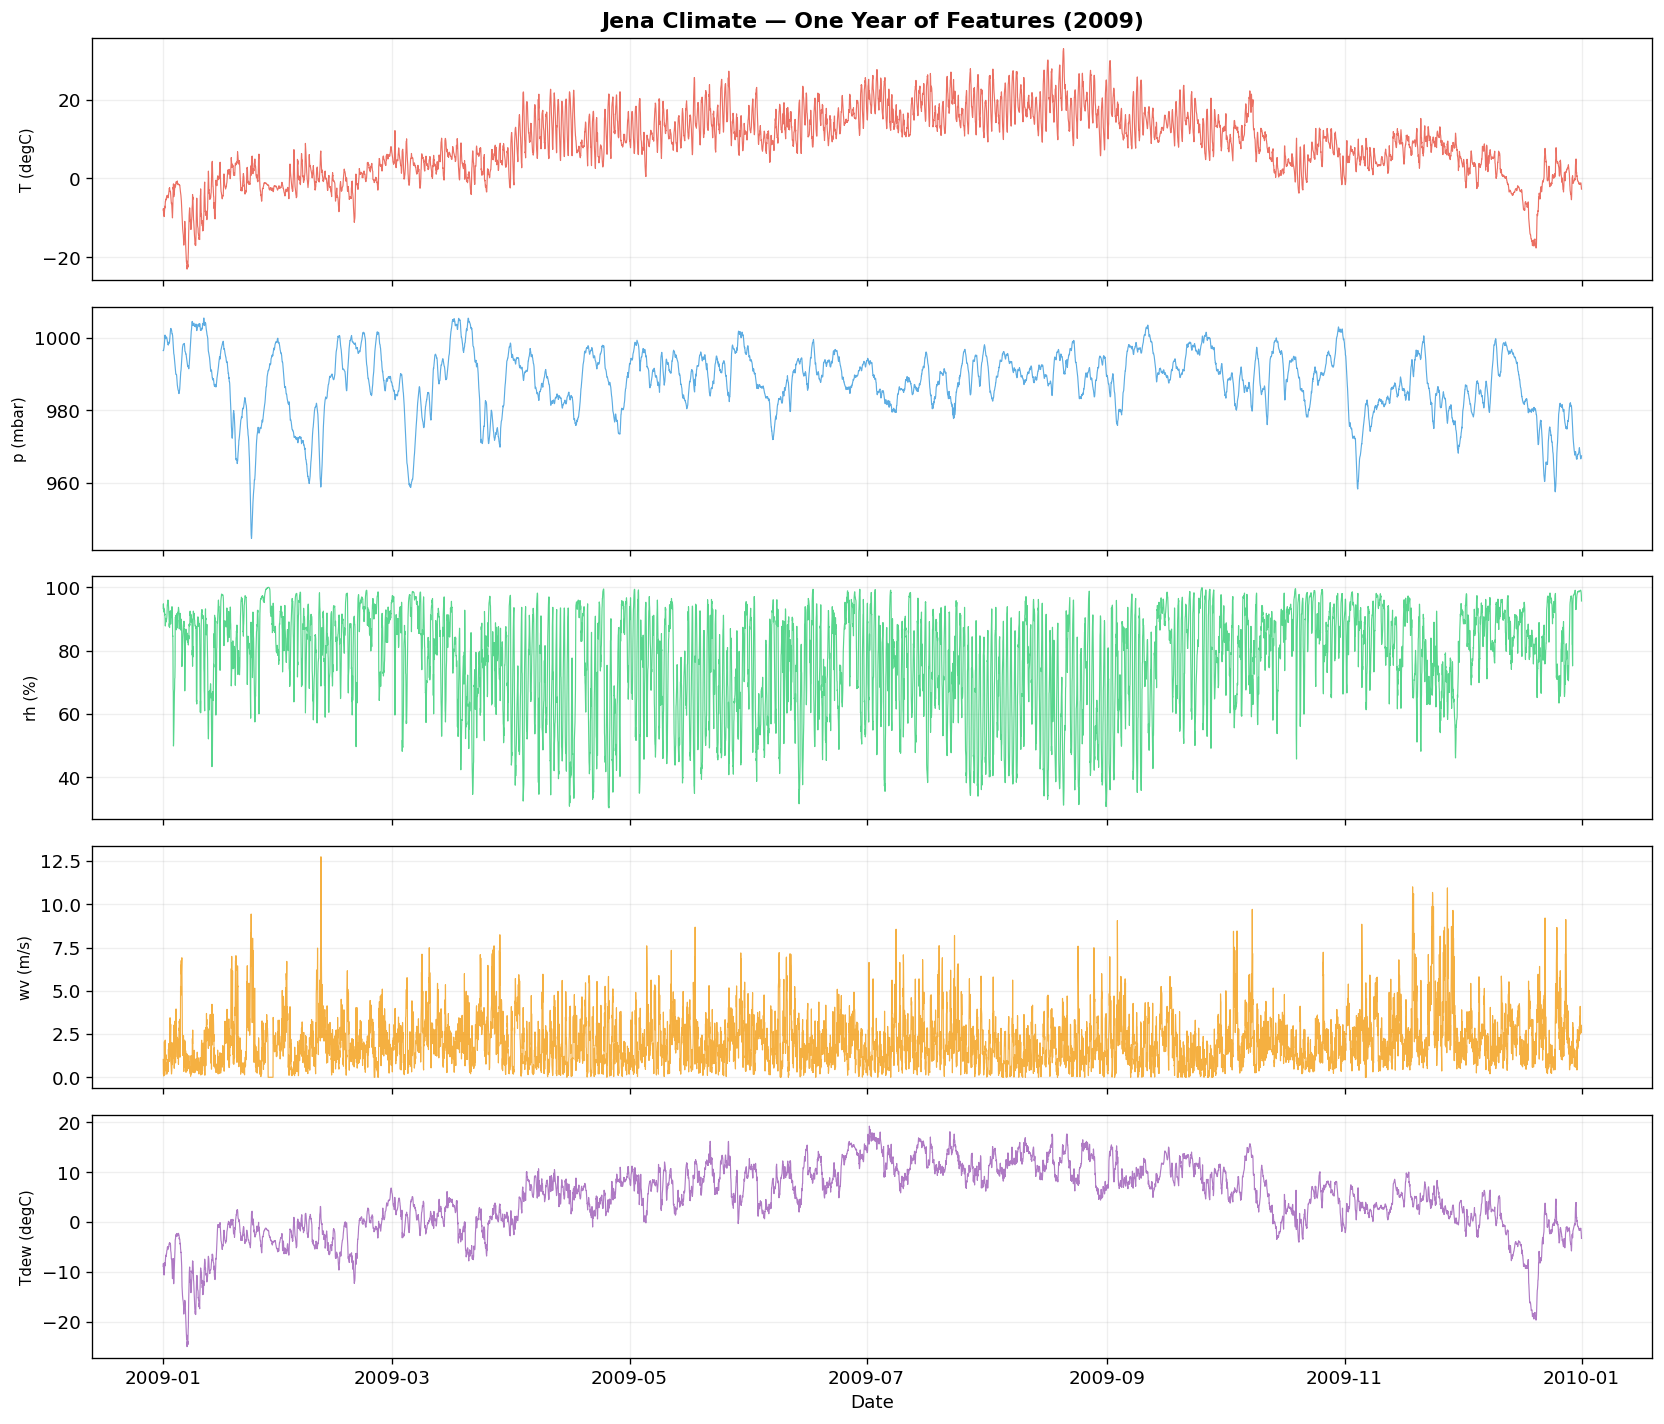

In [12]:
# ── Feature plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(len(features), 1, figsize=(14, 12), sharex=True)
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for ax, feat, color in zip(axes, features, colors):
    ax.plot(df.index[:8760], df[feat].values[:8760],
            linewidth=0.7, color=color, alpha=0.8)
    ax.set_ylabel(feat, fontsize=9)
    ax.grid(alpha=0.2)

axes[0].set_title('Jena Climate — One Year of Features (2009)', fontweight='bold')
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('eda_weather.png', bbox_inches='tight')
plt.show()

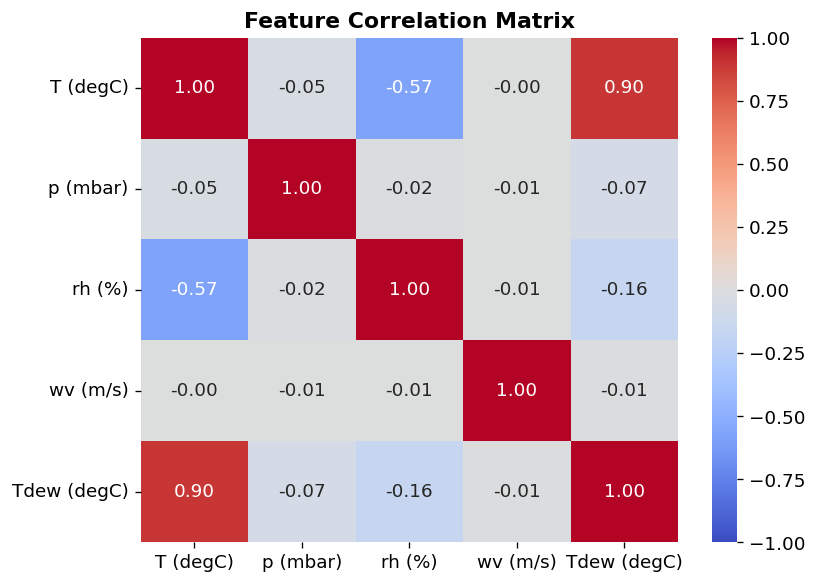

In [13]:
# ── Correlation heatmap ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_weather_corr.png', bbox_inches='tight')
plt.show()

In [14]:
# ── Sliding window explanation ─────────────────────────────────────────
SEQ_LEN, HORIZON = 96, 24
print('Sliding Window Strategy')
print('─' * 40)
print(f'  Input window (X): {SEQ_LEN} hours = {SEQ_LEN} timesteps × {len(features)} features')
print(f'  Forecast horizon (y): next {HORIZON} hours of temperature')
print(f'  Total possible windows: {len(df) - SEQ_LEN - HORIZON + 1:,}')

Sliding Window Strategy
────────────────────────────────────────
  Input window (X): 96 hours = 96 timesteps × 5 features
  Forecast horizon (y): next 24 hours of temperature
  Total possible windows: 69,973


## Module C — Multi30k EN→DE Translation


In [15]:
multi30k = load_dataset('bentrevett/multi30k')
print(multi30k)
print('\nSample pairs:')
for ex in list(multi30k['train'])[:5]:
    print(f'  EN: {ex["en"]}')
    print(f'  DE: {ex["de"]}')
    print()

c:\Users\Jon\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Jon\.cache\huggingface\hub\datasets--bentrevett--multi30k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating test split: 100%|██████████| 1000/1000 [00:00<00:00, 36453.19 examples/s]


DatasetDict({
    train: Dataset({
        features: ['en', 'de'],
        num_rows: 29000
    })
    validation: Dataset({
        features: ['en', 'de'],
        num_rows: 1014
    })
    test: Dataset({
        features: ['en', 'de'],
        num_rows: 1000
    })
})

Sample pairs:
  EN: Two young, White males are outside near many bushes.
  DE: Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.

  EN: Several men in hard hats are operating a giant pulley system.
  DE: Mehrere Männer mit Schutzhelmen bedienen ein Antriebsradsystem.

  EN: A little girl climbing into a wooden playhouse.
  DE: Ein kleines Mädchen klettert in ein Spielhaus aus Holz.

  EN: A man in a blue shirt is standing on a ladder cleaning a window.
  DE: Ein Mann in einem blauen Hemd steht auf einer Leiter und putzt ein Fenster.

  EN: Two men are at the stove preparing food.
  DE: Zwei Männer stehen am Herd und bereiten Essen zu.



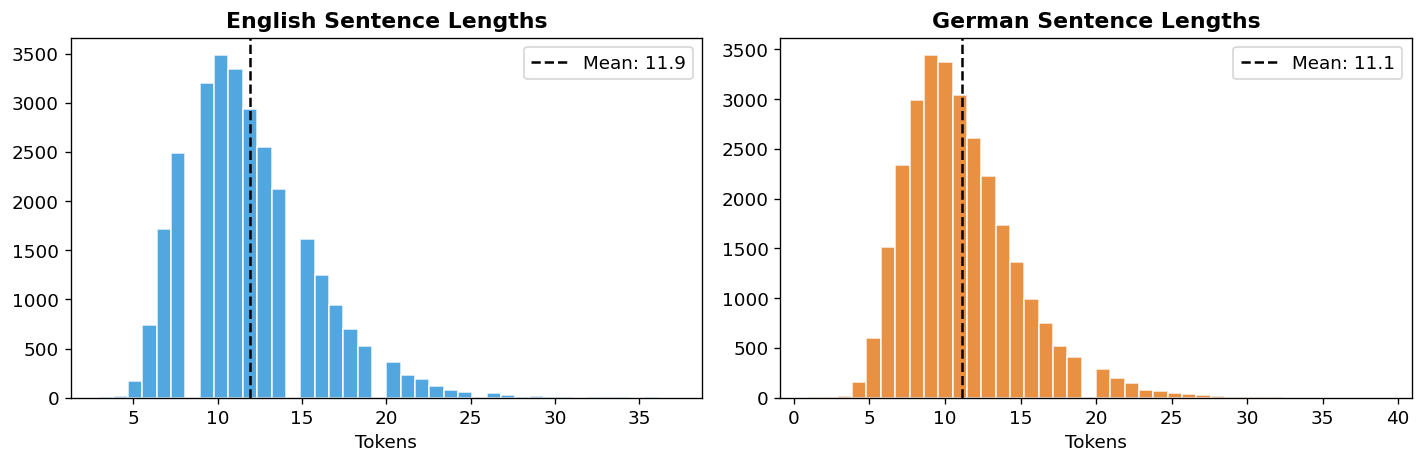

EN  — mean: 11.9, max: 37, 95th pct: 19
DE  — mean: 11.1, max: 39, 95th pct: 18
DE/EN length ratio: 0.940 ± 0.163


In [16]:
# ── Length analysis ────────────────────────────────────────────────────
en_lens = [len(ex['en'].split()) for ex in multi30k['train']]
de_lens = [len(ex['de'].split()) for ex in multi30k['train']]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, lens, lang, color in zip(axes,
    [en_lens, de_lens], ['English', 'German'], ['#3498db', '#e67e22']):
    ax.hist(lens, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(np.mean(lens), color='black', linestyle='--',
               label=f'Mean: {np.mean(lens):.1f}')
    ax.set_title(f'{lang} Sentence Lengths', fontweight='bold')
    ax.set_xlabel('Tokens')
    ax.legend()

plt.tight_layout()
plt.savefig('eda_translation.png', bbox_inches='tight')
plt.show()

print(f'EN  — mean: {np.mean(en_lens):.1f}, max: {max(en_lens)}, 95th pct: {np.percentile(en_lens,95):.0f}')
print(f'DE  — mean: {np.mean(de_lens):.1f}, max: {max(de_lens)}, 95th pct: {np.percentile(de_lens,95):.0f}')

# Length ratio
ratio = np.array(de_lens) / np.array(en_lens)
print(f'DE/EN length ratio: {ratio.mean():.3f} ± {ratio.std():.3f}')

In [17]:
# ── Vocabulary overlap ─────────────────────────────────────────────────
en_counter = Counter(t for ex in multi30k['train'] for t in ex['en'].lower().split())
de_counter = Counter(t for ex in multi30k['train'] for t in ex['de'].lower().split())
print(f'Unique EN tokens: {len(en_counter):,}')
print(f'Unique DE tokens: {len(de_counter):,}')
print(f'Top 10 EN: {en_counter.most_common(10)}')
print(f'Top 10 DE: {de_counter.most_common(10)}')

Unique EN tokens: 14,446
Unique DE tokens: 24,329
Top 10 EN: [('a', 49161), ('in', 14869), ('the', 10951), ('on', 7826), ('man', 7585), ('is', 7522), ('and', 7376), ('of', 6859), ('with', 6175), ('two', 3875)]
Top 10 DE: [('ein', 18753), ('einem', 13711), ('in', 11892), ('eine', 9904), ('und', 8925), ('mit', 8821), ('auf', 8468), ('mann', 7433), ('einer', 6762), ('der', 4986)]
